# ⌨️ Vitara AI: Typing Stress LSTM Training Notebook

Notebook ini dirancang untuk melatih model **Keystroke Dynamics** untuk mendeteksi probabilitas tingkat stres pengguna.
Pendekatan yang digunakan adalah **Klasifikasi Biner** sesuai dengan target metrik AUC-ROC $\ge$ 0.80.

* **Input:** `wpm`, `typing_variance`, `backspace_rate`, dan sekuens `inter_key_timings`
* **Output:** `stress_score` (probabilitas `0.0 - 1.0` dari aktivasi Sigmoid)
* **Environment:** Direkomendasikan dijalankan di **Google Colab (GPU T4)**.


In [12]:
# 1. Setup Environment & Mount Drive
from google.colab import drive
drive.mount('/content/drive')
print("Mounted Google Drive successfully.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Mounted Google Drive successfully.


In [13]:
# Import Library yang dibutuhkan
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, LSTM, Dropout, Masking, Concatenate, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

print("TensorFlow Version:", tf.__version__)
if tf.config.list_physical_devices('GPU'):
    print("GPU is available!")
else:
    print("GPU is NOT available.")


TensorFlow Version: 2.20.0
GPU is available!


## 2. Data Loading & Preprocessing
Pastikan letak `keystrokes.csv` sudah sesuai dengan struktur Google Drive kamu.
Trik **Ambiguity Margin** dapat diaktifkan jika kamu ingin membuang data 'abu-abu' di rentang stress 0.45 - 0.55 saat training untuk mempertegas batas keputusan model.

In [14]:
# Path ke dataset (Sesuaikan jika path di drive mu berbeda)
DATA_PATH = '/content/drive/MyDrive/vitara/data/typing/raw/keystrokes.csv'

# Load data (jika file belum ada, kita buat dummy data untuk testing jalannya notebook)
try:
    df = pd.read_csv(DATA_PATH)
    print(f"Loaded {len(df)} rows of data.")
except FileNotFoundError:
    print("Dataset not found. Generating dummy dataset for testing the notebook pipeline...")
    # Generate Dummy Data for pipeline testing
    np.random.seed(42)
    n_samples = 2000
    df = pd.DataFrame({
        'id': [f'typ_{i:04d}' for i in range(n_samples)],
        'user_id': np.random.choice([f'usr_{i:03d}' for i in range(50)], n_samples),
        'wpm': np.random.normal(55, 10, n_samples),
        'typing_variance': np.random.normal(15, 5, n_samples),
        'backspace_rate': np.random.uniform(0.01, 0.3, n_samples),
        'inter_key_timings': [','.join(map(str, np.random.randint(50, 300, np.random.randint(10, 100)))) for _ in range(n_samples)],
        'stress_label': np.random.uniform(0.0, 1.0, n_samples)
    })
    print("Dummy dataset generated.")

display(df.head())


Loaded 3502 rows of data.


,id,user_id,wpm,typing_variance,backspace_rate,inter_key_timings,stress_label
0,typ_00001,p001,35.8,0.55,0.03,"796,1148,172,200,320,1432,280,196,813,183,712,...",0.19
1,typ_00002,p001,39.8,0.36,0.06,"265,207,97,127,248,65,176,129,191,167,191,57,1...",0.19
2,typ_00003,p002,66.8,0.16,0.08,"1166,147,289,240,180,242,114,146,60,185,170,96...",0.14
3,typ_00004,p002,68.2,0.14,0.07,"112,79,90,56,157,42,207,975,65,501,118,56,96,8...",0.13
4,typ_00005,p003,21.3,4.28,0.05,"485,485,735,92,138,108,87,173,60,122,90,108,67...",0.25


In [15]:
# 2.1 Parsing Sequential Data & Thresholding Biner

# Fungsi pembantu untuk parsing array string
def parse_timings(timing_str):
    if pd.isna(timing_str):
        return []
    return [float(x.strip()) for x in str(timing_str).split(',')]

df['parsed_timings'] = df['inter_key_timings'].apply(parse_timings)

# Thresholding: Mengubah float menjadi biner (0 atau 1)
THRESHOLD = 0.5
df['binary_label'] = (df['stress_label'] >= THRESHOLD).astype(int)

# (OPSIONAL) Ambiguity Margin: Menghapus data di sekitar threshold untuk mempertegas pemisahan kelas
USE_AMBIGUITY_MARGIN = False

if USE_AMBIGUITY_MARGIN:
    margin = 0.05
    mask = (df['stress_label'] < (THRESHOLD - margin)) | (df['stress_label'] > (THRESHOLD + margin))
    print(f"Rows before ambiguity margin filtering: {len(df)}")
    df = df[mask].copy()
    print(f"Rows after ambiguity margin filtering: {len(df)}")

print("Label distribution:")
print(df['binary_label'].value_counts())


Label distribution:
binary_label
1    2503
0     999
Name: count, dtype: int64


In [16]:
# 2.2 Sequence Padding
# Karena panjang ketukan tiap sesi berbeda, kita perlu melakukan padding
# Kita akan mencari persentil ke-95 dari panjang array sebagai batas (MAX_SEQ_LEN)
seq_lengths = df['parsed_timings'].apply(len)
MAX_SEQ_LEN = int(np.percentile(seq_lengths, 95))
print(f"Max Sequence Length (95th percentile): {MAX_SEQ_LEN}")

# Lakukan padding: potong jika kepanjangan, beri angka 0 jika kependekan
from tensorflow.keras.preprocessing.sequence import pad_sequences

X_seq = pad_sequences(
    df['parsed_timings'].values,
    maxlen=MAX_SEQ_LEN,
    padding='post', # Padding di akhir
    truncating='post',
    dtype='float32',
    value=0.0 # Nilai 0.0 akan di-masking nanti oleh model
)

# Expand dimension agar sesuai dengan input LSTM (batch_size, time_steps, features)
X_seq = np.expand_dims(X_seq, axis=-1)
print("Shape X_seq:", X_seq.shape)


Max Sequence Length (95th percentile): 50
Shape X_seq: (3502, 50, 1)


## 3. Train - Validation - Test Split (GroupSplit)
Penting! Kita menggunakan `GroupShuffleSplit` berdasarkan `user_id` untuk mencegah **Data Leakage**. Sesi dari pengguna yang sama TIDAK boleh disebar antara Train dan Test.

In [17]:
# Ekstrak Fitur Statis
static_features = ['wpm', 'typing_variance', 'backspace_rate']
X_static = df[static_features].values
y = df['binary_label'].values
groups = df['user_id'].values

# Split 1: Train (80%) vs Temp (20%)
gss1 = GroupShuffleSplit(n_splits=1, train_size=0.8, random_state=42)
train_idx, temp_idx = next(gss1.split(X_seq, y, groups=groups))

X_seq_train, X_seq_temp = X_seq[train_idx], X_seq[temp_idx]
X_static_train, X_static_temp = X_static[train_idx], X_static[temp_idx]
y_train, y_temp = y[train_idx], y[temp_idx]
groups_temp = groups[temp_idx]

# Split 2: Val (10%) vs Test (10%) - dari sisa 20%
gss2 = GroupShuffleSplit(n_splits=1, train_size=0.5, random_state=42)
val_idx, test_idx = next(gss2.split(X_seq_temp, y_temp, groups=groups_temp))

X_seq_val, X_seq_test = X_seq_temp[val_idx], X_seq_temp[test_idx]
X_static_val, X_static_test = X_static_temp[val_idx], X_static_temp[test_idx]
y_val, y_test = y_temp[val_idx], y_temp[test_idx]

print(f"Train samples: {len(y_train)}")
print(f"Val samples: {len(y_val)}")
print(f"Test samples: {len(y_test)}")


Train samples: 2807
Val samples: 349
Test samples: 346


In [18]:
# 3.1 Feature Scaling
# Scaler hanya boleh di-fit pada data TRAIN
scaler_seq = StandardScaler()
# reshape untuk scaler: (batch_size * timesteps, 1)
X_seq_train_flat = X_seq_train.reshape(-1, 1)
scaler_seq.fit(X_seq_train_flat)

# Mencegah padding '0.0' ikut ter-scale (menggeser mean)
def scale_sequence(X_arr):
    mask = X_arr != 0.0
    X_flat = X_arr.reshape(-1, 1)
    # Lakukan transformasi
    X_scaled = scaler_seq.transform(X_flat)
    X_scaled = X_scaled.reshape(X_arr.shape)
    # Kembalikan yang 0.0 menjadi 0.0
    X_scaled = np.where(mask, X_scaled, 0.0)
    return X_scaled

X_seq_train = scale_sequence(X_seq_train)
X_seq_val = scale_sequence(X_seq_val)
X_seq_test = scale_sequence(X_seq_test)

# Scale fitur statis
scaler_static = StandardScaler()
X_static_train = scaler_static.fit_transform(X_static_train)
X_static_val = scaler_static.transform(X_static_val)
X_static_test = scaler_static.transform(X_static_test)


## 3.2 Save Processed Data to Drive
Menyimpan data yang sudah di-preprocess dan di-split ke folder `processed/` di Google Drive untuk keperluan evaluasi atau *retraining* di masa depan tanpa perlu *preprocessing* ulang dari awal.

In [19]:
# Buat direktori jika belum ada
import os
import numpy as np

PROCESSED_DIR = '/content/drive/MyDrive/vitara/data/typing/processed/'
train_dir = os.path.join(PROCESSED_DIR, 'train')
val_dir = os.path.join(PROCESSED_DIR, 'val')
test_dir = os.path.join(PROCESSED_DIR, 'test')

os.makedirs(train_dir, exist_ok=True)
os.makedirs(val_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)

# Save Train Data
np.save(os.path.join(train_dir, 'X_seq.npy'), X_seq_train)
np.save(os.path.join(train_dir, 'X_static.npy'), X_static_train)
np.save(os.path.join(train_dir, 'y.npy'), y_train)

# Save Val Data
np.save(os.path.join(val_dir, 'X_seq.npy'), X_seq_val)
np.save(os.path.join(val_dir, 'X_static.npy'), X_static_val)
np.save(os.path.join(val_dir, 'y.npy'), y_val)

# Save Test Data
np.save(os.path.join(test_dir, 'X_seq.npy'), X_seq_test)
np.save(os.path.join(test_dir, 'X_static.npy'), X_static_test)
np.save(os.path.join(test_dir, 'y.npy'), y_test)

print(f"Data successfully saved to {PROCESSED_DIR} in train, val, and test folders.")


Data successfully saved to /content/drive/MyDrive/vitara/data/typing/processed/ in train, val, and test folders.


## 4. Model Architecture (Functional API)
Menggabungkan arsitektur RNN/LSTM untuk ketukan waktu, dan Dense Layer untuk fitur statis.
Output menggunakan `sigmoid` untuk klasifikasi biner.

In [20]:
def build_typing_stress_model(seq_len, num_static_features):
    # Cabang 1: Sequential Input (inter_key_timings)
    seq_input = Input(shape=(seq_len, 1), name="seq_input")
    # Masking layer untuk mengabaikan padding value 0.0
    x_seq = Masking(mask_value=0.0)(seq_input)
    x_seq = LSTM(32, return_sequences=False)(x_seq)
    x_seq = BatchNormalization()(x_seq)
    x_seq = Dropout(0.3)(x_seq)

    # Cabang 2: Static Input (wpm, backspace_rate, dsb)
    static_input = Input(shape=(num_static_features,), name="static_input")
    x_stat = Dense(16, activation='relu')(static_input)
    x_stat = BatchNormalization()(x_stat)

    # Penggabungan (Late Fusion secara internal)
    merged = Concatenate()([x_seq, x_stat])

    # Classifier Head
    x = Dense(32, activation='relu')(merged)
    x = Dropout(0.3)(x)
    x = Dense(16, activation='relu')(x)
    output = Dense(1, activation='sigmoid', name="stress_score")(x)

    model = Model(inputs=[seq_input, static_input], outputs=output)
    return model

model = build_typing_stress_model(MAX_SEQ_LEN, X_static_train.shape[1])
model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ seq_input           │ (None, 50, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_1         │ (None, 50, 1)     │          0 │ seq_input[0][0]   │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ masking_1 (Masking) │ (None, 50, 1)     │          0 │ seq_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ any_1 (Any)         │ (None, 50)        │          0 │ not_equal_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 32)        │      4,352 │ masking_1[0][0],  │
│                     │                   │            │ any_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ static_input        │ (None, 3)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32)        │        128 │ lstm_1[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 16)        │         64 │ static_input[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 32)        │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16)        │         64 │ dense_3[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 48)        │          0 │ dropout_2[0][0],  │
│ (Concatenate)       │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 32)        │      1,568 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 32)        │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 16)        │        528 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stress_score        │ (None, 1)         │         17 │ dense_5[0][0]     │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 6,721 (26.25 KB)

 Trainable params: 6,625 (25.88 KB)

 Non-trainable params: 96 (384.00 B)

## 5. Training Pipeline

In [21]:
# Menggunakan Custom Logger dari Vitara AI
import time
import datetime
import os

class VitaraTrainingLogger(tf.keras.callbacks.Callback):
    def __init__(self, log_frequency=1, log_dir=None):
        super(VitaraTrainingLogger, self).__init__()
        self.log_frequency = log_frequency
        self.log_dir = log_dir
        self.train_start_time = None
        self.epoch_start_time = None
        self.log_file_path = None

        if self.log_dir:
            os.makedirs(self.log_dir, exist_ok=True)
            timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
            self.log_file_path = os.path.join(self.log_dir, f"training_log_{timestamp}.txt")

    def _write_log(self, text):
        print(text)
        if self.log_file_path:
            with open(self.log_file_path, 'a', encoding='utf-8') as f:
                f.write(text + "\n")

    def on_train_begin(self, logs=None):
        self.train_start_time = time.time()
        self._write_log("="*80)
        wib_tz = datetime.timezone(datetime.timedelta(hours=7))
        start_time_str = datetime.datetime.now(wib_tz).strftime('%Y-%m-%d %H:%M:%S WIB')
        self._write_log(f"🚀 [Vitara AI] Training Started at {start_time_str}")
        self._write_log("="*80)

    def on_epoch_begin(self, epoch, logs=None):
        self.epoch_start_time = time.time()

    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % self.log_frequency == 0:
            epoch_time = time.time() - self.epoch_start_time
            log_msgs = [f"Epoch {epoch + 1:03d} | {epoch_time:.1f}s"]
            if logs:
                for key, value in logs.items():
                    log_msgs.append(f"{key}: {value:.4f}")
            self._write_log(" | ".join(log_msgs))

    def on_train_end(self, logs=None):
        total_time = time.time() - self.train_start_time
        hours, rem = divmod(total_time, 3600)
        minutes, seconds = divmod(rem, 60)
        self._write_log("="*80)
        self._write_log(f"✅ [Vitara AI] Training Completed in {int(hours):02d}:{int(minutes):02d}:{seconds:.1f}")
        self._write_log("="*80)


In [22]:
def build_typing_stress_model(seq_len, num_static_features):
    # Cabang 1: Sequential Input (inter_key_timings)
    seq_input = Input(shape=(seq_len, 1), name="seq_input")
    # Masking layer untuk mengabaikan padding value 0.0
    x_seq = Masking(mask_value=0.0)(seq_input)
    # FIX: Disable cuDNN for LSTM due to masking limitations with scaled data
    x_seq = LSTM(32, return_sequences=False, use_cudnn=False)(x_seq)
    x_seq = BatchNormalization()(x_seq)
    x_seq = Dropout(0.3)(x_seq)

    # Cabang 2: Static Input (wpm, backspace_rate, dsb)
    static_input = Input(shape=(num_static_features,), name="static_input")
    x_stat = Dense(16, activation='relu')(static_input)
    x_stat = BatchNormalization()(x_stat)

    # Penggabungan (Late Fusion secara internal)
    merged = Concatenate()([x_seq, x_stat])

    # Classifier Head
    x = Dense(32, activation='relu')(merged)
    x = Dropout(0.3)(x)
    x = Dense(16, activation='relu')(x)
    output = Dense(1, activation='sigmoid', name="stress_score")(x)

    model = Model(inputs=[seq_input, static_input], outputs=output)
    return model

# Rebuild the model with the corrected definition
model = build_typing_stress_model(MAX_SEQ_LEN, X_static_train.shape[1])

# Compile Model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=[tf.keras.metrics.AUC(name='auc'), 'accuracy']
)

# Hitung Class Weights untuk menangani Imbalance
from sklearn.utils.class_weight import compute_class_weight
class_weights_arr = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = {0: class_weights_arr[0], 1: class_weights_arr[1]}
print("Class Weights:", class_weight_dict)

# Setup Callbacks
log_path = '/content/drive/MyDrive/vitara/logs/typing'
logger = VitaraTrainingLogger(log_frequency=1, log_dir=log_path)
export_dir = '/content/drive/MyDrive/vitara/models/'
os.makedirs(export_dir, exist_ok=True)
keras_path = os.path.join(export_dir, 'typing_stress_lstm.keras')

from tensorflow.keras.callbacks import TensorBoard
callbacks = [
    logger,
    TensorBoard(log_dir=log_path, histogram_freq=1),
    EarlyStopping(monitor='val_auc', mode='max', patience=15, restore_best_weights=True),
    ModelCheckpoint(keras_path, monitor='val_auc', mode='max', save_best_only=True),
    ReduceLROnPlateau(monitor='val_auc', mode='max', factor=0.5, patience=5, min_lr=1e-5)
]

# Training
EPOCHS = 50
BATCH_SIZE = 32

history = model.fit(
    x=[X_seq_train, X_static_train],
    y=y_train,
    validation_data=([X_seq_val, X_static_val], y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=0 # Matikan verbose default Keras agar log custom VitaraTrainingLogger terlihat rapi
)


Class Weights: {0: np.float64(1.8467105263157895), 1: np.float64(0.6856375183194919)}
🚀 [Vitara AI] Training Started at 2026-05-19 14:04:56 WIB
Epoch 001 | 15.4s | accuracy: 0.8308 | auc: 0.8836 | loss: 0.4389 | val_accuracy: 0.8797 | val_auc: 0.9543 | val_loss: 0.4688
Epoch 002 | 1.0s | accuracy: 0.8771 | auc: 0.9281 | loss: 0.3401 | val_accuracy: 0.9169 | val_auc: 0.9729 | val_loss: 0.3782
Epoch 003 | 0.8s | accuracy: 0.8856 | auc: 0.9443 | loss: 0.3000 | val_accuracy: 0.9284 | val_auc: 0.9771 | val_loss: 0.3175
Epoch 004 | 0.9s | accuracy: 0.8992 | auc: 0.9537 | loss: 0.2751 | val_accuracy: 0.9198 | val_auc: 0.9795 | val_loss: 0.2258
Epoch 005 | 1.2s | accuracy: 0.9024 | auc: 0.9552 | loss: 0.2718 | val_accuracy: 0.9341 | val_auc: 0.9833 | val_loss: 0.1962
Epoch 006 | 1.3s | accuracy: 0.9131 | auc: 0.9655 | loss: 0.2381 | val_accuracy: 0.9284 | val_auc: 0.9836 | val_loss: 0.1852
Epoch 007 | 0.9s | accuracy: 0.9195 | auc: 0.9687 | loss: 0.2255 | val_accuracy: 0.9398 | val_auc: 0.9843

## 6. Evaluation & Visualization

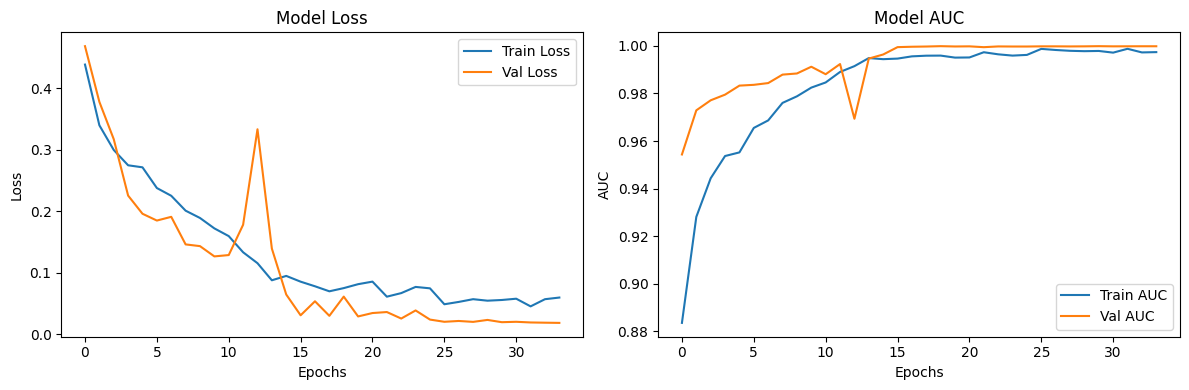

In [23]:
# Plot Training History
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history['loss'], label='Train Loss')
ax1.plot(history.history['val_loss'], label='Val Loss')
ax1.set_title('Model Loss')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.legend()

ax2.plot(history.history['auc'], label='Train AUC')
ax2.plot(history.history['val_auc'], label='Val AUC')
ax2.set_title('Model AUC')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('AUC')
ax2.legend()

plt.tight_layout()
plt.show()


Menyajikan Performa Model pada Data Test (Unseen Users):
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 86ms/step

Classification Report:
              precision    recall  f1-score   support

           0       0.92      1.00      0.96       122
           1       1.00      0.95      0.97       224

    accuracy                           0.97       346
   macro avg       0.96      0.98      0.97       346
weighted avg       0.97      0.97      0.97       346



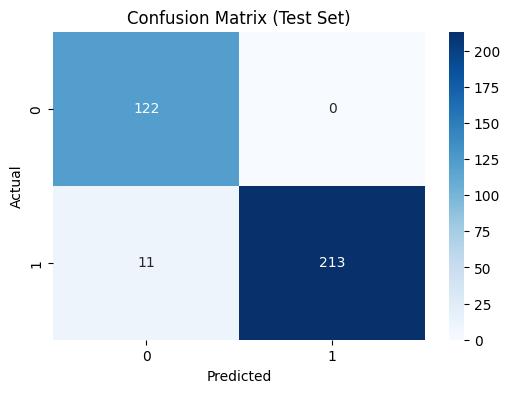

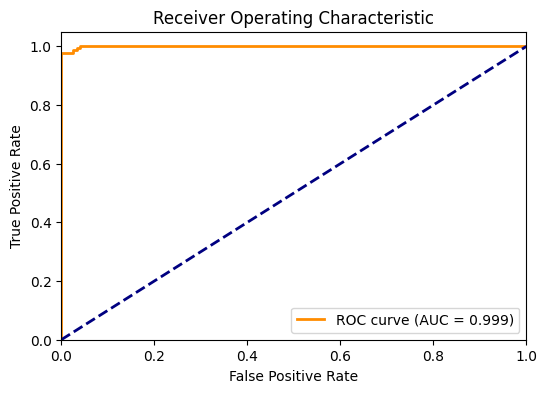

In [24]:
# Evaluasi di Test Set
print("Menyajikan Performa Model pada Data Test (Unseen Users):")

# Dapatkan probabilitas
y_pred_prob = model.predict([X_seq_test, X_static_test]).ravel()
# Konversi ke kelas
y_pred_class = (y_pred_prob >= 0.5).astype(int)

# 1. Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_class))

# 2. Confusion Matrix
plt.figure(figsize=(6,4))
cm = confusion_matrix(y_test, y_pred_class)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix (Test Set)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# 3. ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()


## 7. Model Export (Keras, H5, SavedModel, TFLite)
Mengekspor model yang sudah dilatih ke berbagai format agar siap di-_deploy_ di FastAPI backend (`.keras`/`.h5`/`SavedModel`) maupun di Mobile App (`.tflite`).

In [27]:
# Ekspor ke berbagai format untuk kemudahan Deployment
export_dir = '/content/drive/MyDrive/vitara/models/typing_model/'
os.makedirs(export_dir, exist_ok=True)
tflite_path = os.path.join(export_dir, 'typing_stress_lstm.tflite')
h5_path = os.path.join(export_dir, 'typing_stress_lstm.h5')
savedmodel_path = os.path.join(export_dir, 'typing_stress_lstm_savedmodel')

# 1. Konversi ke TFLite (Mobile / Edge)
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
# FIX: Add target_spec and disable experimental lowering for dynamic tensor lists
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS, tf.lite.OpsSet.SELECT_TF_OPS]
converter._experimental_lower_tensor_list_ops = False
tflite_model = converter.convert()
with open(tflite_path, 'wb') as f:
    f.write(tflite_model)

# 2. Ekspor ke H5 (Legacy Keras Format)
model.save(h5_path)

# 3. Ekspor ke SavedModel (TensorFlow Serving / C++)
try:
    model.export(savedmodel_path)
except AttributeError:
    # Fallback untuk versi TensorFlow/Keras lama
    model.save(savedmodel_path, save_format='tf')

print(f"\n🎉 Models successfully exported to:")
print(f"- Keras (Best Checkpoint) : {keras_path}")
print(f"- TFLite                  : {tflite_path}")
print(f"- H5                      : {h5_path}")
print(f"- SavedModel Dir          : {savedmodel_path}")

Saved artifact at '/tmp/tmpj2ye6_ms'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): List[TensorSpec(shape=(None, 50, 1), dtype=tf.float32, name='seq_input'), TensorSpec(shape=(None, 3), dtype=tf.float32, name='static_input')]
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  136823220384208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136823220386128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136823220387472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136823220381136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136823220386704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136823220387280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136823220387664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136823220386512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136823220386896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136823220384400: Te

Saved artifact at '/content/drive/MyDrive/vitara/models/typing_model/typing_stress_lstm_savedmodel'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): List[TensorSpec(shape=(None, 50, 1), dtype=tf.float32, name='seq_input'), TensorSpec(shape=(None, 3), dtype=tf.float32, name='static_input')]
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  136823220384208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136823220386128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136823220387472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136823220381136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136823220386704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136823220387280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136823220387664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136823220386512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136823220386896: TensorSpe